In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:

df = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [8]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
df.info()

Shape (rows, columns): (301, 9)

Column names: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [13]:
df.describe()
df.describe(include="object")   # summary of categorical columns

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [23]:
#REMOVE DUPLICATES
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (299, 9)


In [24]:
#Unique Values Check
for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    print(f"{col}: {df[col].unique()}")

Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Seller_Type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owner: [0 1 3]


In [25]:
#Drop Rows Missing Critical Fields
df = df.dropna(subset=["Selling_Price", "Present_Price"])
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


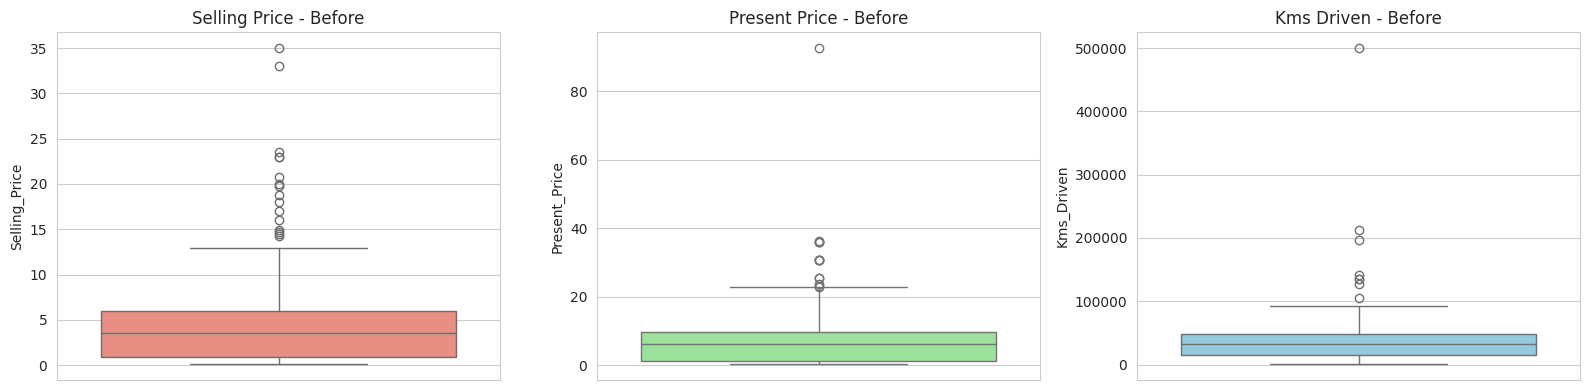

In [26]:
#OUTLIERS BEFORE
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(y=df["Selling_Price"], ax=axes[0], color="salmon")
axes[0].set_title("Selling Price - Before")
sns.boxplot(y=df["Present_Price"], ax=axes[1], color="lightgreen")
axes[1].set_title("Present Price - Before")
sns.boxplot(y=df["Kms_Driven"], ax=axes[2], color="skyblue")
axes[2].set_title("Kms Driven - Before")
plt.tight_layout()
plt.show()

In [27]:
def find_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | valid range = [{lower:.2f}, {upper:.2f}]")
    return lower, upper

low_sp, up_sp = find_outliers_iqr(df, "Selling_Price")
low_pp, up_pp = find_outliers_iqr(df, "Present_Price")
low_km, up_km = find_outliers_iqr(df, "Kms_Driven")

Selling_Price: 16 outliers | valid range = [-6.88, 13.73]
Present_Price: 14 outliers | valid range = [-11.76, 22.80]
Kms_Driven: 8 outliers | valid range = [-35825.25, 99708.75]


In [28]:
#REMOVE OUTLIERS
df_clean = df[
    (df["Selling_Price"].between(low_sp, up_sp)) &
    (df["Present_Price"].between(low_pp, up_pp)) &
    (df["Kms_Driven"].between(low_km, up_km))
]

print("Original rows:", len(df))
print("Rows after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 299
Rows after outlier removal: 276
Rows removed: 23


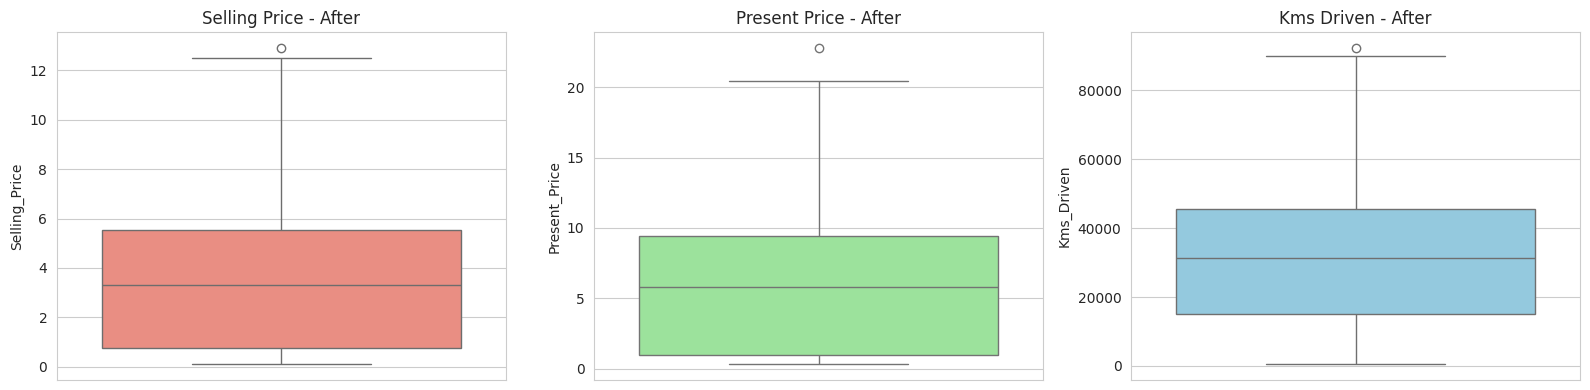

In [29]:
#AFTER OUTLIERS REMOVAL
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(y=df_clean["Selling_Price"], ax=axes[0], color="salmon")
axes[0].set_title("Selling Price - After")
sns.boxplot(y=df_clean["Present_Price"], ax=axes[1], color="lightgreen")
axes[1].set_title("Present Price - After")
sns.boxplot(y=df_clean["Kms_Driven"], ax=axes[2], color="skyblue")
axes[2].set_title("Kms Driven - After")
plt.tight_layout()
plt.show()

In [30]:
#FEATURE ENGINEERING - NEW FEATURES
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Year"]
df["Depreciation_%"] = ((df["Present_Price"] - df["Selling_Price"]) / df["Present_Price"]) * 100
df["Price_per_Km"] = df["Selling_Price"] / df["Kms_Driven"].replace(0, np.nan)

# Same features on the outlier-cleaned dataframe
df_clean["Car_Age"] = CURRENT_YEAR - df_clean["Year"]
df_clean["Depreciation_%"] = ((df_clean["Present_Price"] - df_clean["Selling_Price"]) / df_clean["Present_Price"]) * 100

df[["Car_Name", "Year", "Car_Age", "Selling_Price", "Present_Price", "Depreciation_%"]].head()

/tmp/ipykernel_2392/3258694441.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Car_Age"] = CURRENT_YEAR - df_clean["Year"]
/tmp/ipykernel_2392/3258694441.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Depreciation_%"] = ((df_clean["Present_Price"] - df_clean["Selling_Price"]) / df_clean["Present_Price"]) * 100


,Car_Name,Year,Car_Age,Selling_Price,Present_Price,Depreciation_%
0,ritz,2014,12,3.35,5.59,40.071556
1,sx4,2013,13,4.75,9.54,50.209644
2,ciaz,2017,9,7.25,9.85,26.395939
3,wagon r,2011,15,2.85,4.15,31.325301
4,swift,2014,12,4.60,6.87,33.042213


In [31]:
#BIN CAR AGE INTO CATEGORIES
df["Age_Group"] = pd.cut(df["Car_Age"], bins=[0, 3, 6, 10, 100],
                          labels=["0-3 yrs", "4-6 yrs", "7-10 yrs", "10+ yrs"])
df[["Car_Name", "Car_Age", "Age_Group"]].head()

,Car_Name,Car_Age,Age_Group
0,ritz,12,10+ yrs
1,sx4,13,10+ yrs
2,ciaz,9,7-10 yrs
3,wagon r,15,10+ yrs
4,swift,12,10+ yrs


In [32]:
#AVG PRICE BY FUEL TYPE
df.groupby("Fuel_Type")["Selling_Price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

,mean,median,count
Fuel_Type,,,
Diesel,10.102759,7.60,58
Petrol,3.264184,2.65,239
CNG,3.100000,3.10,2


In [35]:
#Average Price by Transmission
df.groupby("Transmission")["Selling_Price"].agg(["mean", "median", "count"])

,mean,median,count
Transmission,,,
Automatic,9.071795,5.75,39
Manual,3.917308,3.25,260


In [36]:
#Average Price by Seller Type
df.groupby("Seller_Type")["Selling_Price"].agg(["mean", "median", "count"])

,mean,median,count
Seller_Type,,,
Dealer,6.632021,5.250,193
Individual,0.870943,0.515,106


In [37]:
#Average Price by Owner Count
df.groupby("Owner")["Selling_Price"].agg(["mean", "median", "count"])

,mean,median,count
Owner,,,
0,4.687847,3.7,288
1,1.970000,0.8,10
3,2.500000,2.5,1


In [38]:
#Average Price by Age Group
df.groupby("Age_Group", observed=True)["Selling_Price"].agg(["mean", "median", "count"])

,mean,median,count
Age_Group,,,
7-10 yrs,5.640941,4.800,85
10+ yrs,4.172056,3.505,214


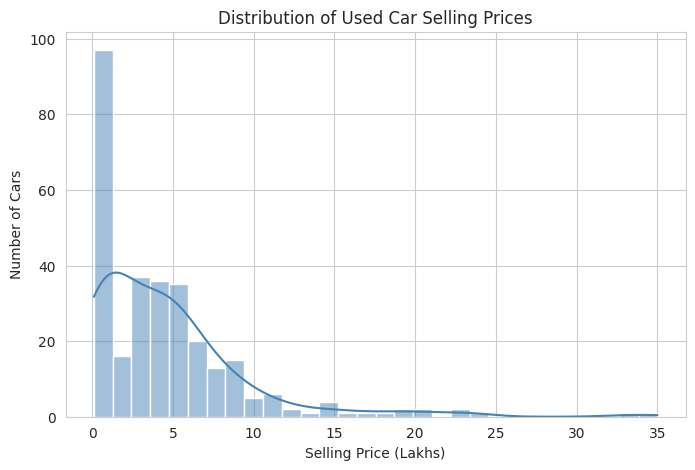

In [39]:
#Selling Price Distribution (Histogram + KDE)
plt.figure()
sns.histplot(df["Selling_Price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.show()

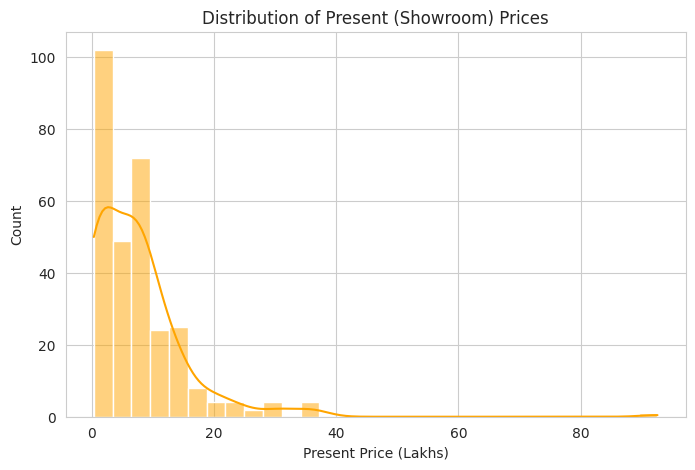

In [40]:
#Present Price Distribution
plt.figure()
sns.histplot(df["Present_Price"], bins=30, kde=True, color="orange")
plt.title("Distribution of Present (Showroom) Prices")
plt.xlabel("Present Price (Lakhs)")
plt.show()

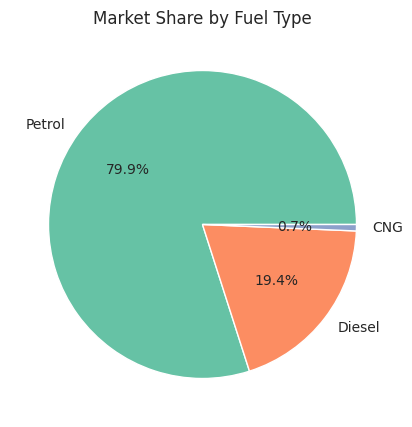

In [41]:
#Pie Chart: Fuel Type Share
plt.figure()
df["Fuel_Type"].value_counts().plot(kind="pie", autopct="%1.1f%%"
,colors=sns.color_palette("Set2"))
plt.title("Market Share by Fuel Type")
plt.ylabel("")
plt.show()

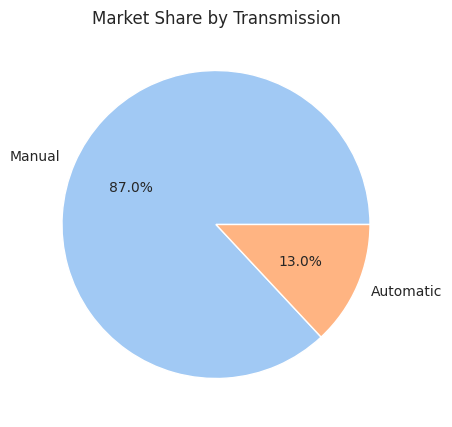

In [42]:
#Pie Chart: Transmission Share
plt.figure()
df["Transmission"].value_counts().plot(kind="pie", autopct="%1.1f%%",
                                        colors=sns.color_palette("pastel"))
plt.title("Market Share by Transmission")
plt.ylabel("")
plt.show()

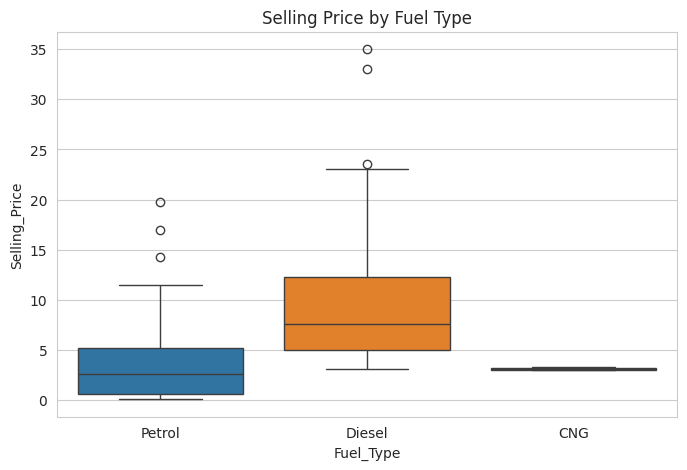

In [43]:
#Boxplot: Price by Fuel Type
plt.figure()
sns.boxplot(x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", data=df, legend=False)
plt.title("Selling Price by Fuel Type")
plt.show()

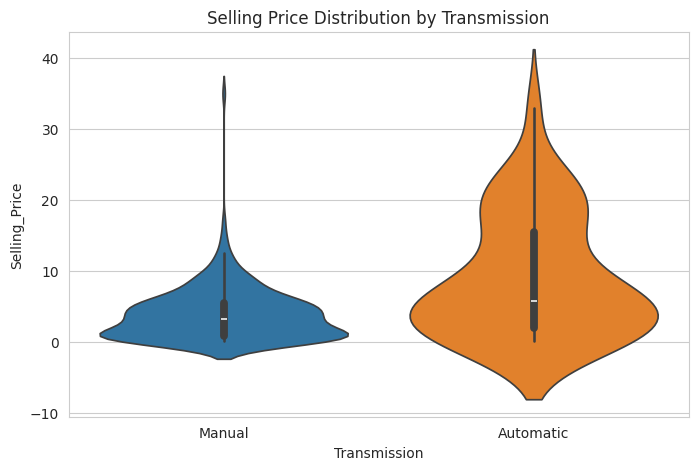

In [44]:
#Violin Plot: Price by Transmission (shows distribution shape, not just quartiles)
plt.figure()
sns.violinplot(x="Transmission", y="Selling_Price", hue="Transmission", data=df, legend=False)
plt.title("Selling Price Distribution by Transmission")
plt.show()

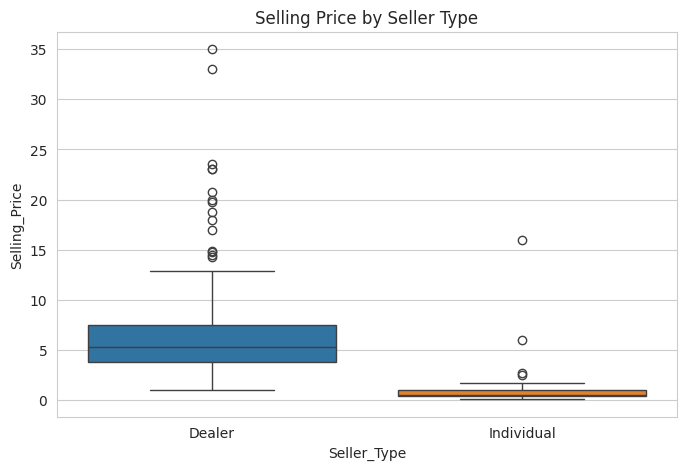

In [45]:
#Boxplot: Price by Seller Type
plt.figure()
sns.boxplot(x="Seller_Type", y="Selling_Price", hue="Seller_Type", data=df, legend=False)
plt.title("Selling Price by Seller Type")
plt.show()

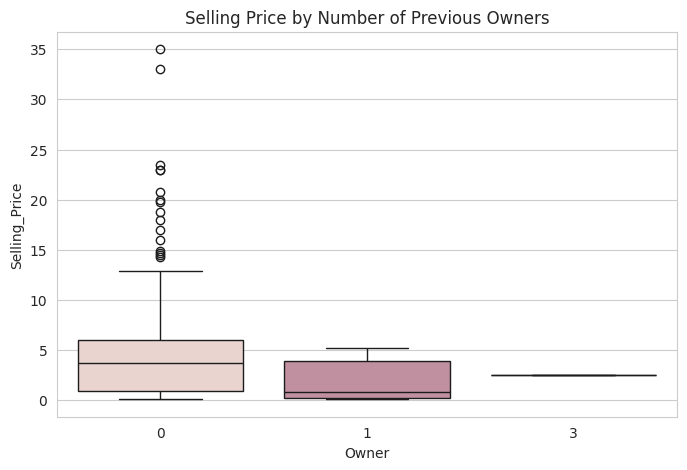

In [46]:
#Boxplot: Price by Owner Count
plt.figure()
sns.boxplot(x="Owner", y="Selling_Price", hue="Owner", data=df, legend=False)
plt.title("Selling Price by Number of Previous Owners")
plt.show()

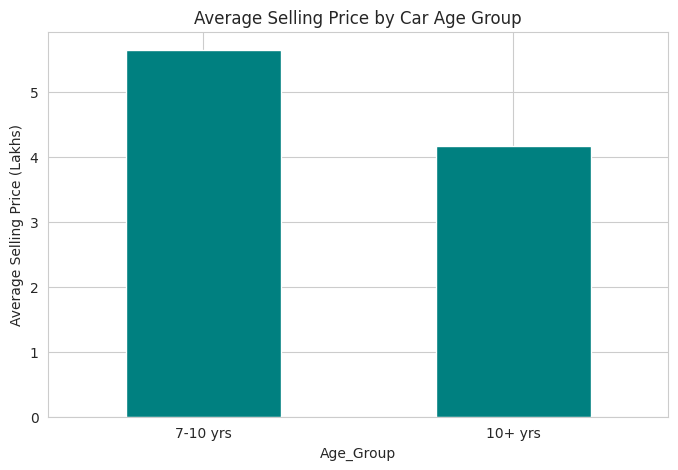

In [47]:
#Bar Chart: Average Price by Age Group
plt.figure()
df.groupby("Age_Group", observed=True)["Selling_Price"].mean().plot(kind="bar", color="teal")
plt.title("Average Selling Price by Car Age Group")
plt.ylabel("Average Selling Price (Lakhs)")
plt.xticks(rotation=0)
plt.show()

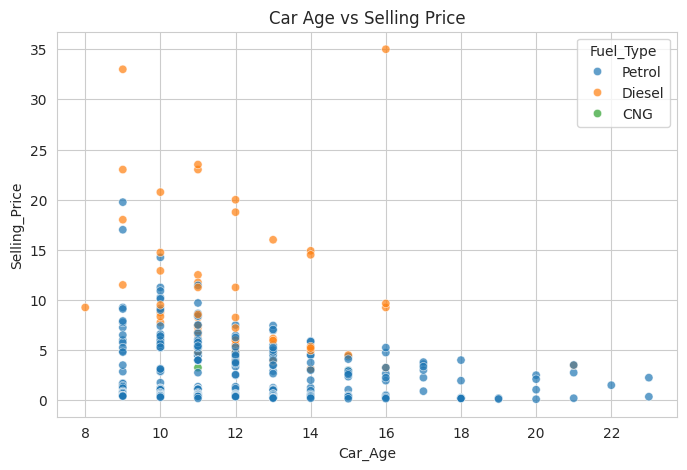

In [48]:
#Scatter: Car Age vs Price
plt.figure()
sns.scatterplot(x="Car_Age", y="Selling_Price", hue="Fuel_Type", data=df, alpha=0.7)
plt.title("Car Age vs Selling Price")
plt.show()

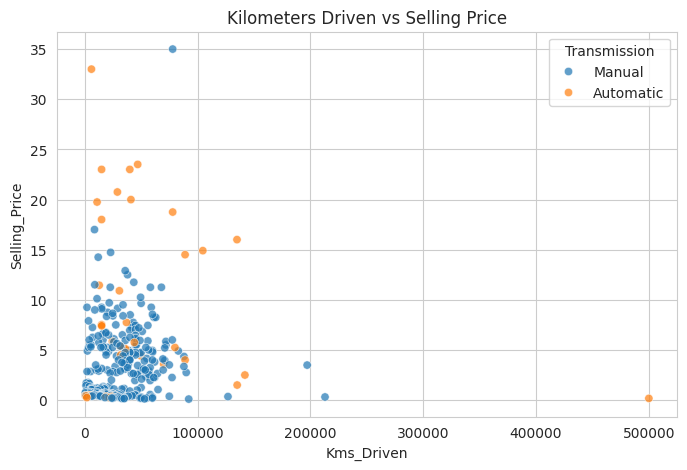

In [49]:
#Scatter: Kms Driven vs Price
plt.figure()
sns.scatterplot(x="Kms_Driven", y="Selling_Price", hue="Transmission", data=df, alpha=0.7)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

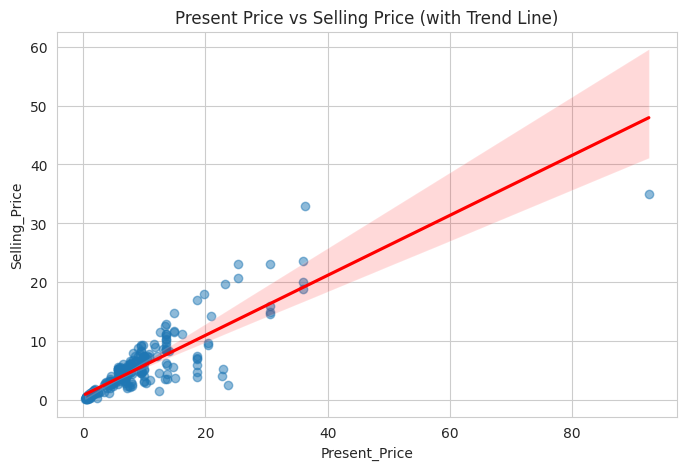

In [50]:
#Regression Plot: Present Price vs Selling Price (with trend line)
plt.figure()
sns.regplot(x="Present_Price", y="Selling_Price", data=df,
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title("Present Price vs Selling Price (with Trend Line)")
plt.show()

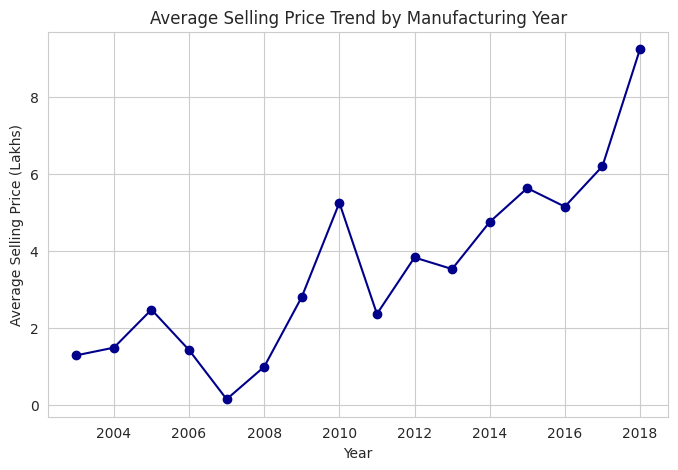

In [51]:
#Line Chart: Average Price Trend by Manufacturing Year
plt.figure()
df.groupby("Year")["Selling_Price"].mean().plot(kind="line", marker="o", color="darkblue")
plt.title("Average Selling Price Trend by Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price (Lakhs)")
plt.show()

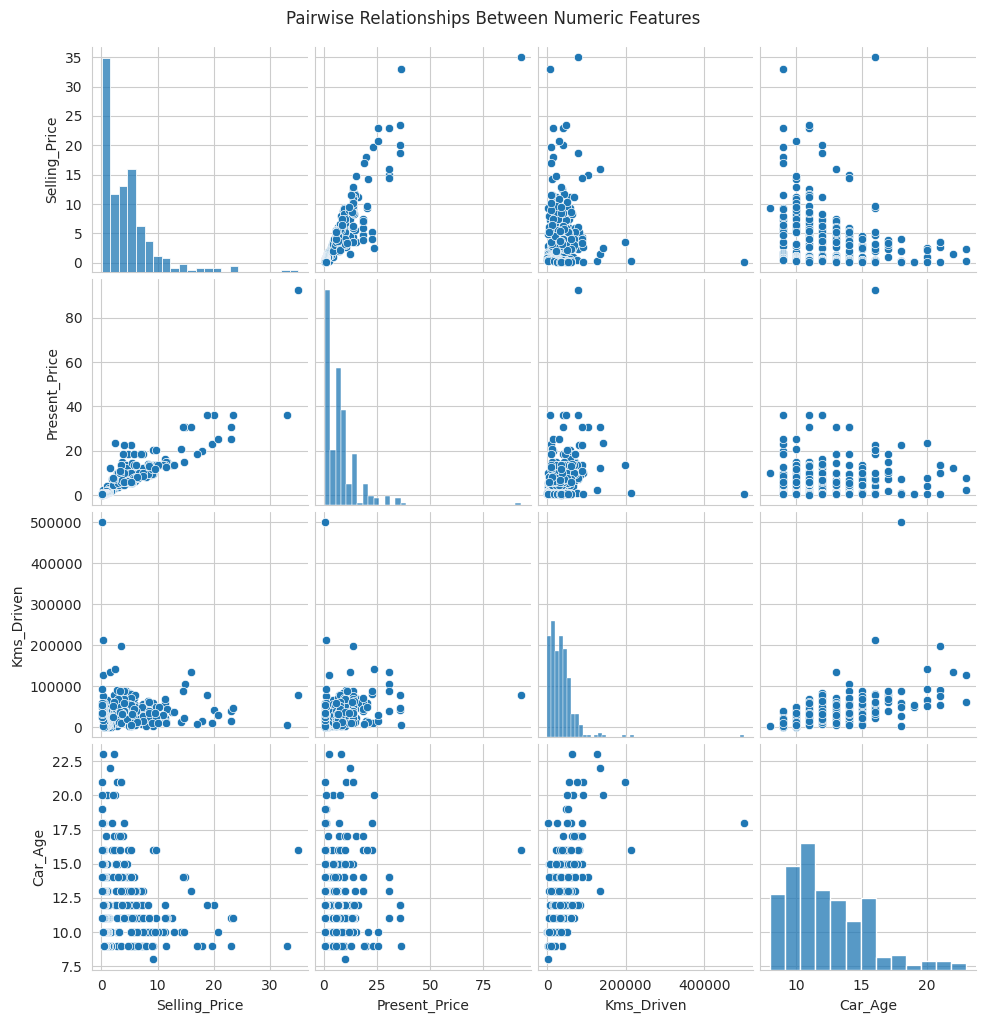

In [52]:
#Pairplot: Multiple Relationships at Once
sns.pairplot(df[["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age"]])
plt.suptitle("Pairwise Relationships Between Numeric Features", y=1.02)
plt.show()

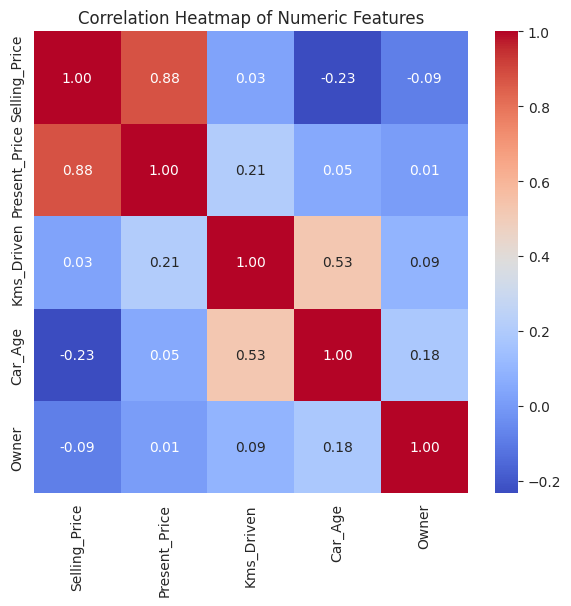

In [53]:
#Correlation Heatmap
numeric_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age", "Owner"]
plt.figure(figsize=(7, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [54]:
#Compare Correlation: Before vs After Outlier Removal
corr_clean = df_clean[["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age"]].corr()
print("Correlation with outliers:\n", corr[["Selling_Price"]])
print("\nCorrelation without outliers:\n", corr_clean[["Selling_Price"]])

Correlation with outliers:
                Selling_Price
Selling_Price       1.000000
Present_Price       0.876378
Kms_Driven          0.028566
Car_Age            -0.234369
Owner              -0.087880

Correlation without outliers:
                Selling_Price
Selling_Price       1.000000
Present_Price       0.843810
Kms_Driven          0.157301
Car_Age            -0.263644


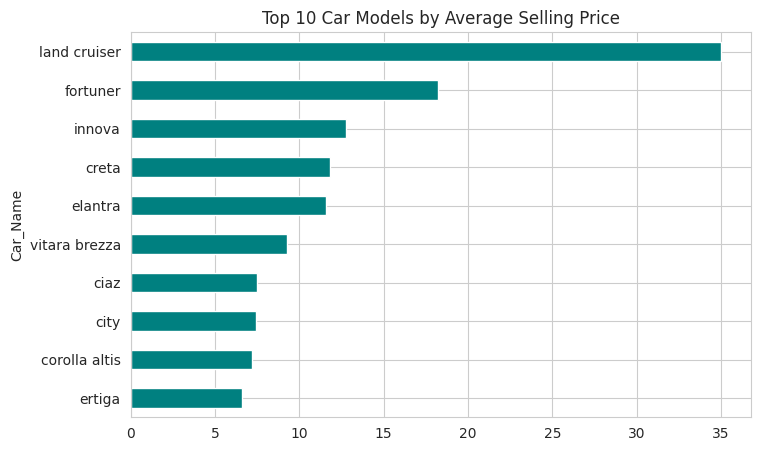

In [55]:
#Top 10 Most Expensive Car Models
top10 = df.groupby("Car_Name")["Selling_Price"].mean().sort_values(ascending=False).head(10)
plt.figure()
top10.plot(kind="barh", color="teal")
plt.title("Top 10 Car Models by Average Selling Price")
plt.gca().invert_yaxis()
plt.show()

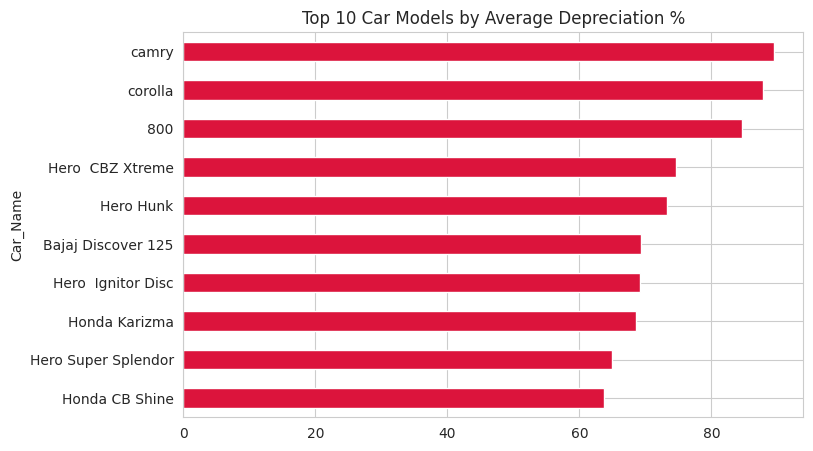

In [56]:
#Top 10 Cars by Highest Depreciation %
top_depr = df.groupby("Car_Name")["Depreciation_%"].mean().sort_values(ascending=False).head(10)
plt.figure()
top_depr.plot(kind="barh", color="crimson")
plt.title("Top 10 Car Models by Average Depreciation %")
plt.gca().invert_yaxis()
plt.show()

In [58]:
df["Fuel_Type"].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


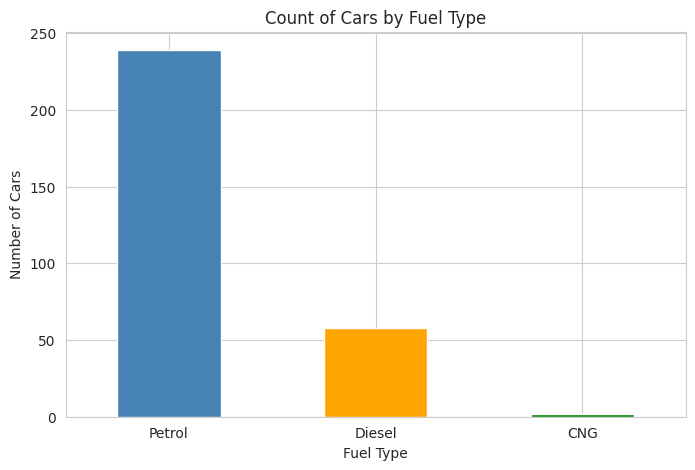

In [59]:
plt.figure()
df["Fuel_Type"].value_counts().plot(kind="bar", color=["steelblue", "orange", "green"])
plt.title("Count of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

In [60]:
print("===== KEY INSIGHTS =====\n")
print("Average selling price:", round(df['Selling_Price'].mean(), 2), "Lakhs")
print("Average car age:", round(df['Car_Age'].mean(), 1), "years")
print("Average depreciation:", round(df['Depreciation_%'].mean(), 1), "%")
print("Outliers removed:", len(df) - len(df_clean), "rows out of", len(df))
print("\nCorrelation with Selling_Price:")
print(corr["Selling_Price"].sort_values(ascending=False))
print("\nFuel type distribution:\n", df["Fuel_Type"].value_counts())
print("\nTransmission distribution:\n", df["Transmission"].value_counts())
print("\nMost expensive model on average:", top10.index[0], "-", round(top10.iloc[0], 2), "Lakhs")
print("Highest depreciating model on average:", top_depr.index[0], "-", round(top_depr.iloc[0], 1), "%")

===== KEY INSIGHTS =====

Average selling price: 4.59 Lakhs
Average car age: 12.4 years
Average depreciation: 36.6 %
Outliers removed: 23 rows out of 299

Correlation with Selling_Price:
Selling_Price    1.000000
Present_Price    0.876378
Kms_Driven       0.028566
Owner           -0.087880
Car_Age         -0.234369
Name: Selling_Price, dtype: float64

Fuel type distribution:
 Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Transmission distribution:
 Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Most expensive model on average: land cruiser - 35.0 Lakhs
Highest depreciating model on average: camry - 89.5 %
